# LUMOS evaluation

## Setup

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr
from pybaselines import polynomial, whittaker
from scipy.optimize import linear_sum_assignment
from scipy.signal import savgol_filter

import lumos
from lumos.metrics import pearson_r, psnr, scale_invariant_psnr, spectral_angle_mapper
from lumos.vae_module import VAEModule

In [8]:
# Resolved from the installed package so it does not depend on the kernel cwd.
CHECKPOINT_DIR = Path(lumos.__file__).resolve().parent / "checkpoints"
SPLIT = "test"

# "last" is the final state of a run. Use "best" to take the lowest
# val_recon_loss, which tracks reconstruction quality only loosely.
CHECKPOINT_SELECT = "last"

# Metrics use this window for every dataset so models trained on different
# crops stay comparable. None uses each store's full axis.
EVAL_WINDOW = (400.0, 1800.0)

DATA = Path("~/Developments/Raman/oracle/data/processed").expanduser()
GLASGOW = DATA / "glasgow/glasgow_16_trimmed_smoothed.zarr"
FISH = DATA / "fish/fish_6frame.zarr"
BIO = DATA / "bio/bio_16_noisy.zarr"

# One entry per model, paired with the store it was trained on. Labels key every
# result dict, so they must be unique.
#
# These four tell the variable-window story on glasgow. All are cosine over
# 2000 epochs; they differ in encoder width, in whether the input window was
# sampled during training, and in whether the test spectra were fitted.
RUNS = [
    dict(label="0.49M uniform", zarr=GLASGOW,
         run="glasgow_16_trimmed_smoothed_mog_t16_z64_h128_lr0.0005_20260825_213754"),
    dict(label="0.49M uniform, held out", zarr=GLASGOW,
         run="glasgow_16_trimmed_smoothed_mog_t16_z64_h128_lr0.0005_20260826_020853"),
    dict(label="0.49M fixed window", zarr=GLASGOW,
         run="glasgow_16_trimmed_smoothed_mog_t16_z64_h128_lr0.0005_20260826_015023"),
    dict(label="4.00M fixed window", zarr=GLASGOW,
         run="glasgow_16_trimmed_smoothed_mog_t16_z64_h128_lr0.0005_20260816_162145"),
]

# Classical baselines, computed once per dataset.
SAVGOL_WINDOW, SAVGOL_ORDER = 11, 3
AIRPLS_LAM, IMODPOLY_ORDER = 1e6, 5

print(f"checkpoints: {CHECKPOINT_DIR}")

checkpoints: /home/tom/Developments/lumos/src/lumos/checkpoints


## Helpers

In [9]:
def best_checkpoint(run_dir, select=CHECKPOINT_SELECT):
    """Path to one checkpoint in a run directory.

    "last" takes last.ckpt, "best" the epoch file with the lowest
    val_recon_loss. Falls back to whichever exists.
    """
    run_dir = Path(run_dir)
    if not run_dir.is_dir():
        available = sorted(p.name for p in CHECKPOINT_DIR.iterdir() if p.is_dir())
        raise FileNotFoundError(
            f"no run directory {run_dir}\navailable:\n  " + "\n  ".join(available[-10:])
        )
    last = run_dir / "last.ckpt"
    epochs = sorted(run_dir.glob("epoch=*.ckpt"))
    if select == "last" and last.exists():
        return last
    if epochs:
        return min(epochs, key=lambda f: float(f.stem.split("val_recon_loss=")[1]))
    if last.exists():
        return last
    raise FileNotFoundError(f"no checkpoints in {run_dir}")


def load_model(run):
    path = best_checkpoint(CHECKPOINT_DIR / run)
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    # Checkpoints predating decoder_dim need it inferred from the weights.
    decoder_dim = ckpt["state_dict"]["model.decoder.trunk_shared.0.weight"].shape[0]
    model = VAEModule.load_from_checkpoint(
        path,
        map_location="cuda" if torch.cuda.is_available() else "cpu",
        strict=False,
        decoder_dim=decoder_dim,
    )
    model.eval()
    return model, ckpt["hyper_parameters"], path.name

In [10]:
def load_data(zarr_path, split=SPLIT):
    """Read one split of a store into plain arrays.

    Ground-truth fields are present in synthetic stores and in the real ones
    that ship a derived reference; the identification metrics need the
    fluorophore-level fields and are skipped without them.
    """
    ds = xr.open_zarr(str(zarr_path))
    idx = np.where(ds["split"].values == split)[0]
    frame_duration = float(ds.attrs.get("frame_duration_s", 0.1))
    gt_var = "gt_raman_smoothed" if "gt_raman_smoothed" in ds else "gt_raman"

    def optional(name):
        return ds[name].values[idx] if name in ds else None

    return dict(
        name=Path(str(zarr_path)).name,
        idx=idx,
        frame_duration=frame_duration,
        wn=ds.coords["wavenumber"].values,
        ts=ds["time_series"].values[idx],
        gt=ds[gt_var].values[idx] / frame_duration,
        labels=np.array([str(v) for v in ds["labels"].values[idx]]),
        n_early=ds["n_early_actual"].values[idx],
        long_exposure=ds["input_long_exposure"].values[idx],
        bases_gt=optional("fluorophore_bases_gt"),
        rates_gt=optional("decay_rates_gt"),
        abund_gt=optional("abundances_gt"),
        dye_names=optional("fluorophore_name"),
    )

In [11]:
def predict_lumos(model, data, batch=8):
    """Recovered Raman, decay rates and abundances for every spectrum."""
    n_times = model.hparams.n_times_train
    std = model.model.dataset_std
    device = next(model.parameters()).device
    raman, rates, abundances = [], [], []
    with torch.no_grad():
        for i in range(0, len(data["ts"]), batch):
            x = data["ts"][i:i + batch, :, :n_times].astype(np.float32)
            x = torch.from_numpy(x).to(device) / std
            _, _, _, lam, ab, ram, _ = model.model(x, sample=False)
            raman.append(ram.cpu().numpy())
            rates.append(lam.cpu().numpy())
            abundances.append(ab.cpu().numpy())
    return tuple(np.concatenate(v, 0) for v in (raman, rates, abundances))


def debaseline(spectra, method="airpls", smooth=True):
    """Remove a smooth background from each spectrum.

    smooth=True also applies a Savitzky-Golay filter, which is what the
    classical baseline methods do as a correction pipeline. For metrics use
    smooth=False, so the comparison is not blurred as well as detrended.
    """
    out = np.empty_like(spectra, dtype=np.float64)
    for i, s in enumerate(spectra):
        s = s.astype(np.float64)
        if smooth:
            s = savgol_filter(s, SAVGOL_WINDOW, SAVGOL_ORDER)
        if method == "airpls":
            base, _ = whittaker.iarpls(s, lam=AIRPLS_LAM)
        else:
            base, _ = polynomial.imodpoly(s, poly_order=IMODPOLY_ORDER)
        out[i] = s - base
    return out


def eval_mask(wn):
    """Restrict a wavenumber axis to the common evaluation window."""
    if EVAL_WINDOW is None:
        return np.ones(len(wn), dtype=bool)
    return (wn >= EVAL_WINDOW[0]) & (wn <= EVAL_WINDOW[1])

## Load models and predict

`datasets` is keyed by store name, `predictions` by `(store, method)`, and
`model_info` by model label. Each model's own dataset is stored alongside it so
later cells do not have to look it up.

In [12]:
datasets, predictions, model_info, latents = {}, {}, {}, {}

labels = [cfg["label"] for cfg in RUNS]
duplicates = {lab for lab in labels if labels.count(lab) > 1}
if duplicates:
    raise ValueError(f"RUNS labels must be unique, repeated: {sorted(duplicates)}")

for cfg in RUNS:
    name = Path(str(cfg["zarr"])).name
    if name not in datasets:
        datasets[name] = load_data(cfg["zarr"])
        d = datasets[name]
        # Classical correction of the long exposure: the store's precomputed sum
        # of the first n_early frames, as counts per second. Photon-matched to a
        # model that sees all n_early frames, generous to one that sees fewer,
        # so a matched baseline is added per model below.
        rate = d["long_exposure"] / (d["n_early"][:, None] * d["frame_duration"])
        predictions[(name, "iAirPLS (long exp)")] = debaseline(rate, "airpls")
        predictions[(name, "iModPoly (long exp)")] = debaseline(rate, "imodpoly")
        print(f"{name}: {len(d['idx'])} samples, W={len(d['wn'])}")

    d = datasets[name]
    model, hparams, ckpt = load_model(cfg["run"])
    if hparams["n_wavenumbers"] != len(d["wn"]):
        raise ValueError(
            f"{cfg['label']}: model expects W={hparams['n_wavenumbers']} but "
            f"{name} has W={len(d['wn'])}. Pair each model with its own store."
        )
    raman, rates, abundances = predict_lumos(model, d)
    predictions[(name, cfg["label"])] = raman
    latents[cfg["label"]] = dict(rates=rates, abundances=abundances)
    model_info[cfg["label"]] = dict(
        model=model, hparams=hparams, data=d, checkpoint=ckpt,
        n_fluorophores=hparams.get("n_fluorophores"),
        decay_mode=hparams.get("decay_mode", "per_sample"),
    )
    # Classical baseline on exactly the frames this model saw, so the two are
    # compared at the same photon budget.
    n_t = hparams["n_times_train"]
    if (name, f"iAirPLS ({n_t}f)") not in predictions:
        matched = d["ts"][:, :, :n_t].sum(2) / (n_t * d["frame_duration"])
        predictions[(name, f"iAirPLS ({n_t}f)")] = debaseline(matched, "airpls")
        predictions[(name, f"iModPoly ({n_t}f)")] = debaseline(matched, "imodpoly")

    print(f"  {cfg['label']:22s} F={hparams.get('n_fluorophores'):<3} "
          f"T={hparams.get('n_times_train'):<3} "
          f"t_sampling={hparams.get('t_sampling', '') or 'fixed':<8} <- {ckpt}")

glasgow_16_trimmed_smoothed.zarr: 54 samples, W=593
[VAE init] raman_mode=pseudo_voigt  n_raman_peaks=300
[VAE init] head_abundance: weight_norm=5.55  bias=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  (softplus -> [0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996])
  0.49M uniform          F=16  T=16  t_sampling=uniform  <- last.ckpt
[VAE init] raman_mode=pseudo_voigt  n_raman_peaks=300
[VAE init] head_abundance: weight_norm=5.531  bias=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  (softplus -> [0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.69314718246459

## Metrics

Recovered Raman against `gt_raman`, over the evaluation window, reported two
ways.

**As recovered** compares the raw spectra. On real stores `gt_raman` is derived
rather than measured, and on fish it is not fully bleached, so it still carries
some fluorescence. A model that leaves fluorescence in its Raman output scores
*better* on that target than it should, which inverts the ranking: a badly
fitted fish model scores Pearson 0.572 here against 0.556 for a good one.

**Baseline removed** strips a smooth background from both sides with airPLS
before comparing, so only peak agreement is scored. On the same two fish models
that gives 0.620 and 0.911, in the right order. This is the row to trust wherever
the target is a derived reference rather than a true Raman spectrum.

In [13]:
METRICS = {
    "PSNR": psnr,
    "SI-PSNR": scale_invariant_psnr,
    "Pearson": pearson_r,
    "SAM": spectral_angle_mapper,
}


def score(gt, pred):
    return {k: np.mean([fn(gt[i], pred[i]) for i in range(len(gt))])
            for k, fn in METRICS.items()}


rows = []
for (name, method), pred in predictions.items():
    d = datasets[name]
    mask = eval_mask(d["wn"])
    gt, pr = d["gt"][:, mask], pred[:, mask]
    for (a, b), tag in [((gt, pr), "as recovered"),
                        ((debaseline(gt, smooth=False),
                          debaseline(pr, smooth=False)), "baseline removed")]:
        rows.append(dict(dataset=name, target=tag, method=method,
                         W=int(mask.sum()), **score(a, b)))

results = pd.DataFrame(rows).set_index(["dataset", "target", "method"]).sort_index()
print(f"window {EVAL_WINDOW} cm^-1" if EVAL_WINDOW else "full axis")
results.round(3)

/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/pybaselines/whittaker.py:490: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
  new_weights, exit_early = _weighting._iarpls(y, baseline, i)
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/pybaselines/whittaker.py:490: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
  new_weights, exit_early = _weighting._iarpls(y, baseline, i)
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/pybaselines/whittaker.py:490: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
  new_weights, exit_early = _weighting._iarpls(y, baseline, i)
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/pybaselines/whittaker.py:490: ParameterWarning: almost all baseline points are below the data, indicating

window (400.0, 1800.0) cm^-1


/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/pybaselines/whittaker.py:490: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
  new_weights, exit_early = _weighting._iarpls(y, baseline, i)


W  \
dataset                          target           method                         
glasgow_16_trimmed_smoothed.zarr as recovered     0.49M fixed window       593   
                                                  0.49M uniform            593   
                                                  0.49M uniform, held out  593   
                                                  4.00M fixed window       593   
                                                  iAirPLS (16f)            593   
                                                  iAirPLS (long exp)       593   
                                                  iModPoly (16f)           593   
                                                  iModPoly (long exp)      593   
                                 baseline removed 0.49M fixed window       593   
                                                  0.49M uniform            593   
                                                  0.49M uniform, held out  593   
                                                  4.00M fixed window       593   
                                                  iAirPLS (16f)            593   
                                                  iAirPLS (long exp)       593   
                                                  iModPoly (16f)           593   
                                                  iModPoly (long exp)      593   

                                                                             PSNR  \
dataset                          target           method                            
glasgow_16_trimmed_smoothed.zarr as recovered     0.49M fixed window       19.657   
                                                  0.49M uniform            19.349   
                                                  0.49M uniform, held out  18.905   
                                                  4.00M fixed window       19.425   
                                                  iAirPLS (16f)            17.586   
                                                  iAirPLS (long exp)       17.586   
                                                  iModPoly (16f)           15.241   
                                                  iModPoly (long exp)      15.241   
                                 baseline removed 0.49M fixed window       20.815   
                                                  0.49M uniform            20.661   
                                                  0.49M uniform, held out  20.212   
                                                  4.00M fixed window       20.645   
                                                  iAirPLS (16f)            18.312   
                                                  iAirPLS (long exp)       18.312   
                                                  iModPoly (16f)           19.196   
                                                  iModPoly (long exp)      19.196   

                                                                           SI-PSNR  \
dataset                          target           method                             
glasgow_16_trimmed_smoothed.zarr as recovered     0.49M fixed window        23.558   
                                                  0.49M uniform             23.507   
                                                  0.49M uniform, held out   23.040   
                                                  4.00M fixed window        23.628   
                                                  iAirPLS (16f)             22.498   
                                                  iAirPLS (long exp)        22.498   
                                                  iModPoly (16f)            19.824   
                                                  iModPoly (long exp)       19.824   
                                 baseline removed 0.49M fixed window        23.393   
                                                  0.49M uniform             23.433   
                                     

## Performance against input window length

The claim under test: one model trained with `t_sampling="uniform"` serves any
number of input frames, where a fixed-window model only works at the length it
was trained on.

Each model is fed its full window and then progressively fewer frames, down to
a single one. Classical correction is included at each length, applied to the
sum of the same frames, so the two are compared at equal photon budget rather
than giving the baseline a longer exposure.


PSNR  SI-PSNR  Pearson     SAM
method                  T                                   
0.49M fixed window      1  -19.468   13.680    0.038  59.998
                        2   -5.718   13.678    0.060  64.006
                        4  -29.724   13.649    0.014  61.388
                        8  -10.354   13.752   -0.076  66.531
                        16  19.657   23.558    0.940  15.873
0.49M uniform           1   16.949   22.402    0.927  17.614
                        2   17.732   22.943    0.931  16.846
                        4   17.996   22.962    0.930  16.926
                        8   18.363   23.052    0.931  16.875
                        16  19.349   23.507    0.940  16.015
0.49M uniform, held out 1   16.405   21.797    0.917  19.020
                        2   17.073   21.956    0.917  18.728
                        4   17.429   22.128    0.918  18.470
                        8   18.145   22.525    0.927  17.590
                        16  18.905   23.040    0.936  16.550
4.00M fixed window      1  -16.565   13.647   -0.064  67.949
                        2  -30.446   13.676   -0.010  60.204
                        4  -13.316   13.900    0.197  58.042
                        8    5.395   17.208    0.700  31.907
                        16  19.425   23.628    0.939  16.053
classical airpls        1   12.002   16.707    0.667  37.863
                        2   14.293   18.210    0.762  31.049
                        4   15.299   19.627    0.826  26.022
                        8   17.123   21.427    0.879  20.984
                        16  17.586   22.498    0.885  19.438
classical imodpoly      1   11.082   15.858    0.603  48.936
                        2   12.617   16.860    0.700  43.584
                        4   13.758   17.926    0.774  39.041
                        8   14.620   18.917    0.827  35.417
                        16  15.241   19.824    0.863  32.767

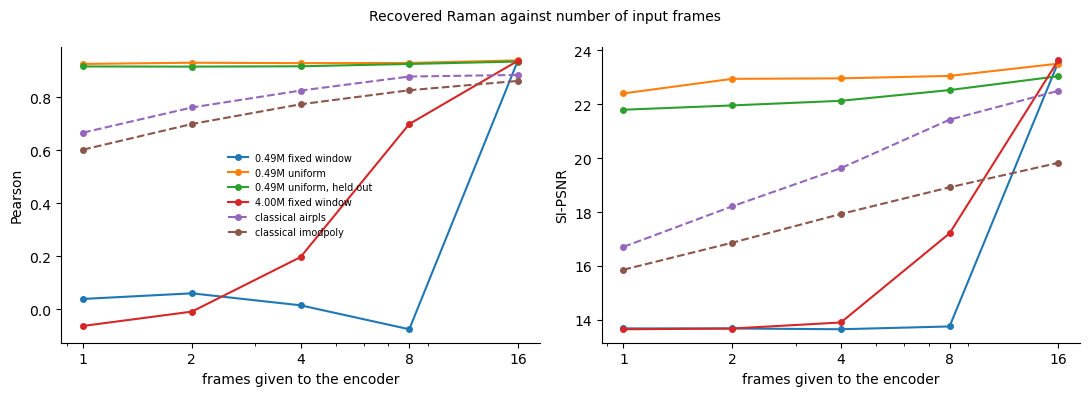

In [14]:
T_GRID = [16, 8, 4, 2, 1]

rows = []
for label, info in model_info.items():
    m, d = info["model"], info["data"]
    std = m.model.dataset_std
    device = next(m.parameters()).device
    mask = eval_mask(d["wn"])
    gt = d["gt"][:, mask]
    n_max = m.hparams.n_times_train
    x_full = torch.from_numpy(d["ts"][:, :, :n_max].astype(np.float32)).to(device) / std

    for T in [t for t in T_GRID if t <= n_max]:
        with torch.no_grad():
            _, _, _, _, _, raman, _ = m.model(x_full[:, :, :T], sample=False)
        pred = raman.cpu().numpy()[:, mask]
        rows.append(dict(method=label, T=T, **score(gt, pred)))

# Classical correction of the same frames, as the reference at each length.
for name, d in datasets.items():
    mask = eval_mask(d["wn"])
    gt = d["gt"][:, mask]
    for T in T_GRID:
        summed = d["ts"][:, :, :T].sum(2) / (T * d["frame_duration"])
        for method in ("airpls", "imodpoly"):
            pred = debaseline(summed, method)[:, mask]
            rows.append(dict(method=f"classical {method}", T=T, **score(gt, pred)))

window = pd.DataFrame(rows).set_index(["method", "T"]).sort_index()
display(window.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for method, grp in window.reset_index().groupby("method"):
    grp = grp.sort_values("T")
    style = "--" if method.startswith("classical") else "-"
    for ax, metric in zip(axes, ("Pearson", "SI-PSNR")):
        ax.plot(grp["T"], grp[metric], style, marker="o", ms=4, label=method)
for ax, metric in zip(axes, ("Pearson", "SI-PSNR")):
    ax.set(xlabel="frames given to the encoder", ylabel=metric, xscale="log")
    ax.set_xticks(T_GRID)
    ax.set_xticklabels(T_GRID)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=7, frameon=False)
fig.suptitle("Recovered Raman against number of input frames", fontsize=10)
plt.tight_layout()
plt.show()


### Predictions at each window length

The table above says performance is flat as frames are removed. This shows what
that looks like: for a few spectra, the same model's recovered Raman at every
window length, over the ground truth. A uniformly trained model should give
nearly the same curve each time; a fixed-window one diverges as soon as it is
given anything other than its trained length.

Classical correction of a single frame is drawn for contrast, since that is the
alternative in the regime a flow measurement would sit in.


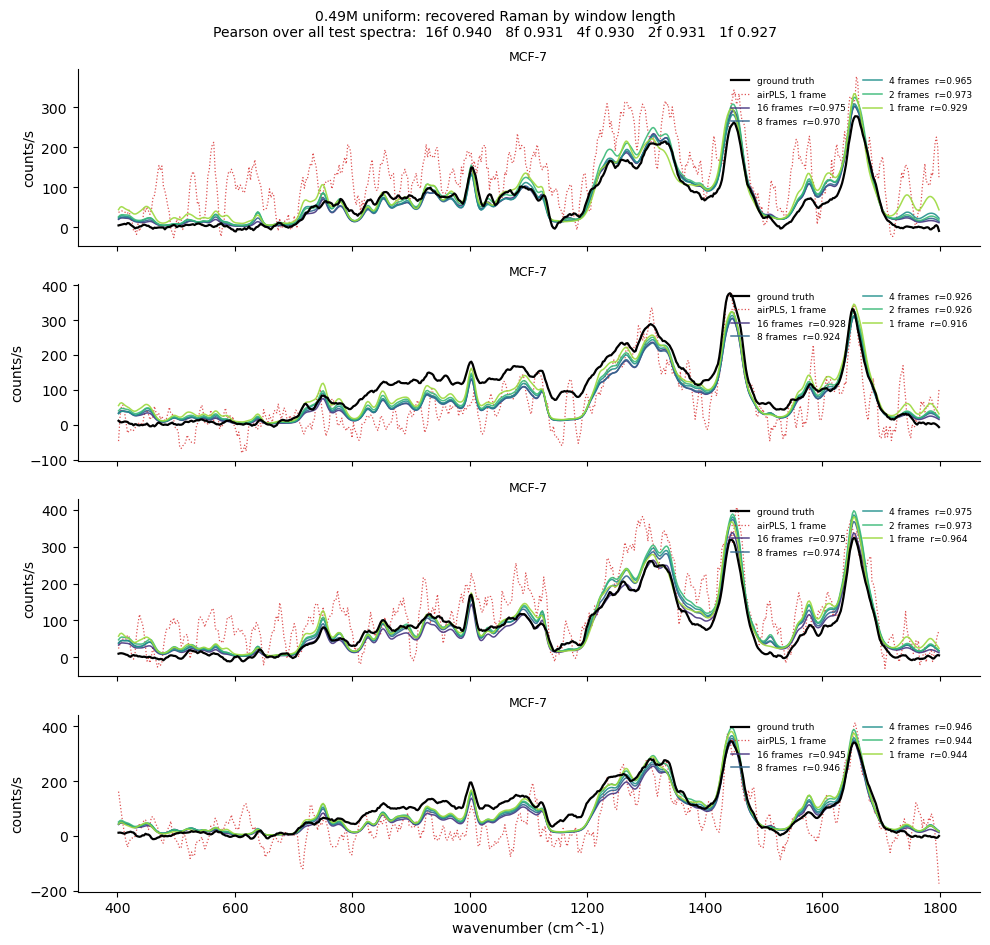

In [26]:
N_SHOW = 4
QUALITATIVE_MODEL = next(iter(model_info))   # first entry in RUNS

info = model_info[QUALITATIVE_MODEL]
m, d = info["model"], info["data"]
std = m.model.dataset_std
device = next(m.parameters()).device
mask = eval_mask(d["wn"])
n_max = m.hparams.n_times_train
grid = [t for t in T_GRID if t <= n_max]
x_full = torch.from_numpy(d["ts"][:, :, :n_max].astype(np.float32)).to(device) / std

# Recovered Raman at each window length, plus its overall Pearson for the legend.
preds, overall = {}, {}
for T in grid:
    with torch.no_grad():
        _, _, _, _, _, raman, _ = m.model(x_full[:, :, :T], sample=False)
    preds[T] = raman.cpu().numpy()
    overall[T] = np.mean([
        pearson_r(d["gt"][i][mask], preds[T][i][mask]) for i in range(len(d["gt"]))
    ])

single = debaseline(d["ts"][:, :, 0] / d["frame_duration"], "airpls")

colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(grid)))
fig, axes = plt.subplots(N_SHOW, 1, figsize=(10, 2.4 * N_SHOW), sharex=True)
for i, ax in enumerate(np.atleast_1d(axes)):
    ax.plot(d["wn"][mask], d["gt"][i][mask], color="black", lw=1.6,
            label="ground truth", zorder=5)
    ax.plot(d["wn"][mask], single[i][mask], color="tab:red", lw=0.9, ls=":",
            alpha=0.8, label="airPLS, 1 frame")
    for colour, T in zip(colours, grid):
        r = pearson_r(d["gt"][i][mask], preds[T][i][mask])
        ax.plot(d["wn"][mask], preds[T][i][mask], color=colour, lw=1.1, alpha=0.9,
                label=f"{T} frame{'s' if T > 1 else ''}  r={r:.3f}")
    ax.set_ylabel("counts/s")
    ax.set_title(d["labels"][i], fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=6.5, frameon=False, ncol=2, loc="upper right")
axes[-1].set_xlabel("wavenumber (cm^-1)")
summary = "   ".join(f"{T}f {overall[T]:.3f}" for T in grid)
fig.suptitle(f"{QUALITATIVE_MODEL}: recovered Raman by window length\n"
             f"Pearson over all test spectra:  {summary}", fontsize=10)
plt.tight_layout()
plt.show()


## Recovered spectra

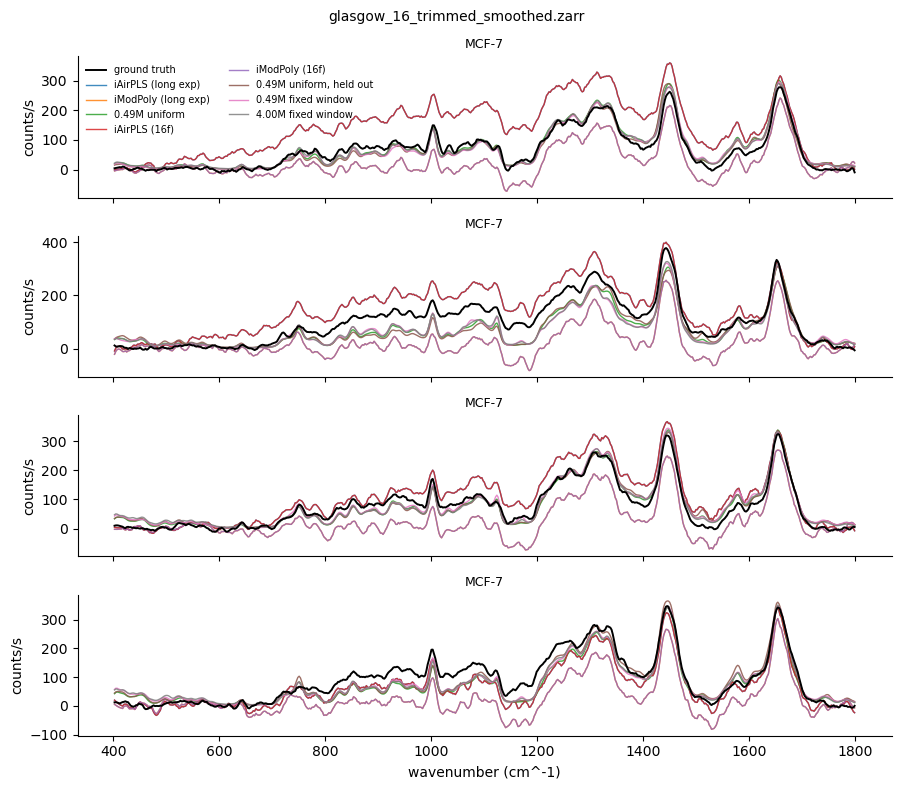

In [15]:
N_SHOW = 4

for name, d in datasets.items():
    methods = [(key[1], pred) for key, pred in predictions.items() if key[0] == name]
    mask = eval_mask(d["wn"])
    fig, axes = plt.subplots(N_SHOW, 1, figsize=(9, 2.0 * N_SHOW), sharex=True)
    for i, ax in enumerate(np.atleast_1d(axes)):
        ax.plot(d["wn"][mask], d["gt"][i][mask], color="black", lw=1.4,
                label="ground truth", zorder=5)
        for method, pred in methods:
            ax.plot(d["wn"][mask], pred[i][mask], lw=1.0, alpha=0.85, label=method)
        ax.set_ylabel("counts/s")
        ax.set_title(d["labels"][i], fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].legend(fontsize=7, frameon=False, ncol=2)
    axes[-1].set_xlabel("wavenumber (cm^-1)")
    fig.suptitle(name, fontsize=10)
    plt.tight_layout()
    plt.show()

## Decomposition detail

Six panels for a single spectrum: the input frames, the fit, the Raman and
fluorescence split at `t=0`, how each component decays, the learned bases, and
the reconstruction error over time.

The fluorescence is built from the model's own components rather than by
subtracting the Raman from the input, so the three curves in the third panel are
independent predictions and their sum is a genuine check.

In [16]:
def visualise_decomposition(label, sample=0, crop=EVAL_WINDOW, n_show=None):
    """Decomposition of one spectrum. n_show limits components, largest first."""
    info = model_info[label]
    m, d = info["model"], info["data"]
    wn, fd = d["wn"], d["frame_duration"]
    mask = eval_mask(wn) if crop is not None else np.ones(len(wn), bool)
    n_times = m.hparams.n_times_train
    std = m.model.dataset_std
    device = next(m.parameters()).device

    x = torch.from_numpy(d["ts"][sample].astype(np.float32)).to(device) / std  # [W, T]
    t_all = m.t_full.detach().cpu().numpy()
    n_t = min(x.shape[1], len(t_all))

    with torch.no_grad():
        _, _, _, lam, ab, raman, bases = m.model(x[None, :, :n_times], sample=False)
        recon, _ = m.model.physics_forward(
            lam, ab, raman, bases, time_values=m.t_full[:n_t].to(device)
        )

    # physics_forward already returns physical counts per frame.
    recon = recon[0].T.cpu().numpy()                 # [T, W]
    observed = (x.T.cpu().numpy() * std)[:n_t]       # [T, W]
    raman_frame = raman[0].cpu().numpy() * fd        # counts/frame
    bases_np = bases.cpu().numpy()
    lam_np, ab_np = lam[0].cpu().numpy(), ab[0].cpu().numpy()

    # fluorescence(t) = sum_i a_i * B_i(nu) * exp(-lambda_i * t)
    decay = np.exp(-lam_np[None, :] * t_all[:n_t, None])   # [T, F]
    component = ab_np[:, None] * bases_np                  # [F, W]
    fluorescence = decay @ component                       # [T, W]

    closure = np.abs(observed[0] - (raman_frame + fluorescence[0])).mean()
    print(f"{label} sample {sample}: mean |observed - (raman + fluorescence)| "
          f"at t=0 = {closure:.3f} counts")

    order = np.argsort(-ab_np)
    k = len(order) if n_show is None else min(n_show, len(order))
    colours = plt.cm.viridis(np.linspace(0, 0.9, n_t))
    fig, ax = plt.subplots(2, 3, figsize=(17, 8))

    a = ax[0, 0]
    for t in range(n_t):
        a.plot(wn[mask], observed[t][mask], color=colours[t], lw=0.7, alpha=0.75)
    a.set(title=f"input, {n_t} frames (dark = early)", ylabel="counts/frame")

    a = ax[0, 1]
    for t in range(0, n_t, max(1, n_t // 6)):
        a.plot(wn[mask], observed[t][mask], color=colours[t], lw=0.8, alpha=0.6)
        a.plot(wn[mask], recon[t][mask], color=colours[t], lw=0.9, ls="--")
    a.plot([], [], "k-", label="observed")
    a.plot([], [], "k--", label="reconstructed")
    a.legend(fontsize=7, frameon=False)
    a.set(title="fit")

    a = ax[0, 2]
    a.plot(wn[mask], observed[0][mask], color="0.6", lw=1.0, label="observed t=0")
    a.plot(wn[mask], fluorescence[0][mask], color="tab:blue", lw=1.2, label="fluorescence")
    a.plot(wn[mask], raman_frame[mask], color="tab:orange", lw=1.4, label="Raman")
    a.plot(wn[mask], (raman_frame + fluorescence[0])[mask], color="tab:green",
           lw=0.9, ls="--", label="sum")
    a.plot(wn[mask], d["gt"][sample][mask] * fd, color="black", lw=1.0, ls=":",
           label="ground-truth Raman")
    a.legend(fontsize=7, frameon=False)
    a.set(title="decomposition at t=0")

    a = ax[1, 0]
    for i in order[:k]:
        a.plot(t_all[:n_t], decay[:, i] * component[i].sum(), lw=1.2,
               label=f"c{i}  {lam_np[i]:.2f} s^-1")
    a.plot(t_all[:n_t], fluorescence.sum(1), "k-", lw=1.6, label="total")
    a.axvline(t_all[n_times - 1], color="k", ls=":", lw=1)
    a.text(t_all[n_times - 1], a.get_ylim()[1], " end of training window",
           fontsize=6, va="top")
    a.legend(fontsize=6, frameon=False, ncol=2)
    a.set(title="component decay", xlabel="time (s)")

    a = ax[1, 1]
    for i in order[:k]:
        a.plot(wn[mask], (bases_np[i] / bases_np[i].max())[mask], lw=1.0, label=f"c{i}")
    if d["bases_gt"] is not None:
        for g in d["bases_gt"][sample]:
            a.plot(wn[mask], (g / g.max())[mask], color="black", lw=0.9, ls="--", alpha=0.7)
        a.plot([], [], "k--", label="true")
    a.legend(fontsize=6, frameon=False, ncol=2)
    a.set(title="bases (peak-normalised)")

    a = ax[1, 2]
    a.semilogy(t_all[:n_t], ((observed - recon) ** 2).mean(1), "k-", lw=1.2)
    a.axvline(t_all[n_times - 1], color="k", ls=":", lw=1)
    a.set(title="reconstruction MSE over time", xlabel="time (s)")

    for a in ax.ravel():
        a.spines[["top", "right"]].set_visible(False)
        a.tick_params(labelsize=7)
        if not a.get_xlabel():
            a.set_xlabel("wavenumber (cm^-1)", fontsize=7)
    fig.suptitle(f"{label}  |  sample {sample} ({d['labels'][sample]})", fontsize=10)
    plt.tight_layout()
    plt.show()

glasgow new sample 10: mean |observed - (raman + fluorescence)| at t=0 = 8.801 counts


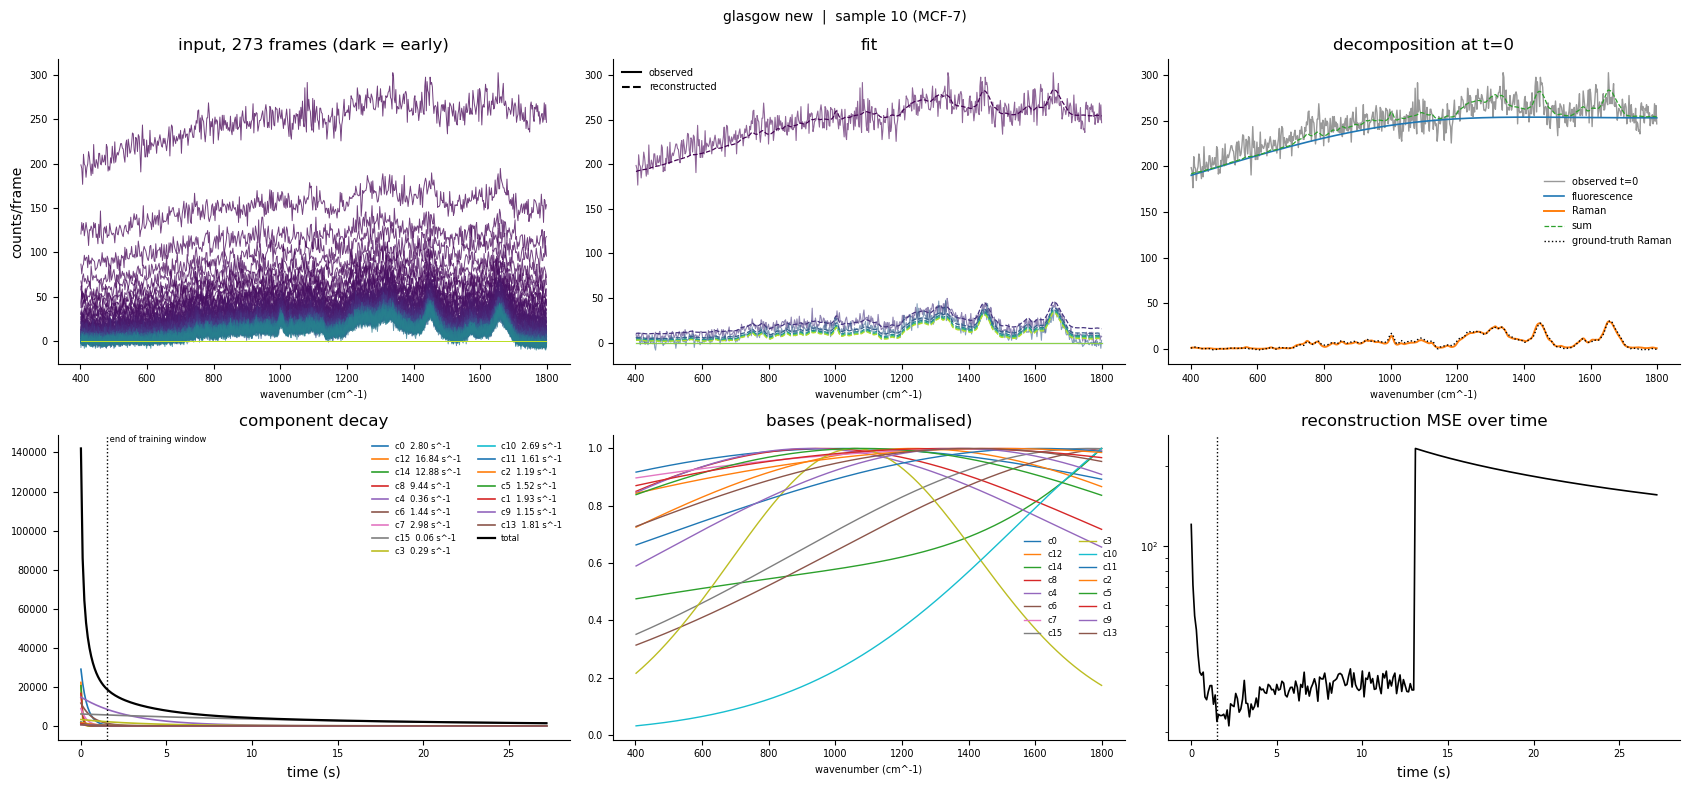

In [24]:
for label in model_info:
    visualise_decomposition(label, sample=10)

## Learned fluorophore bases

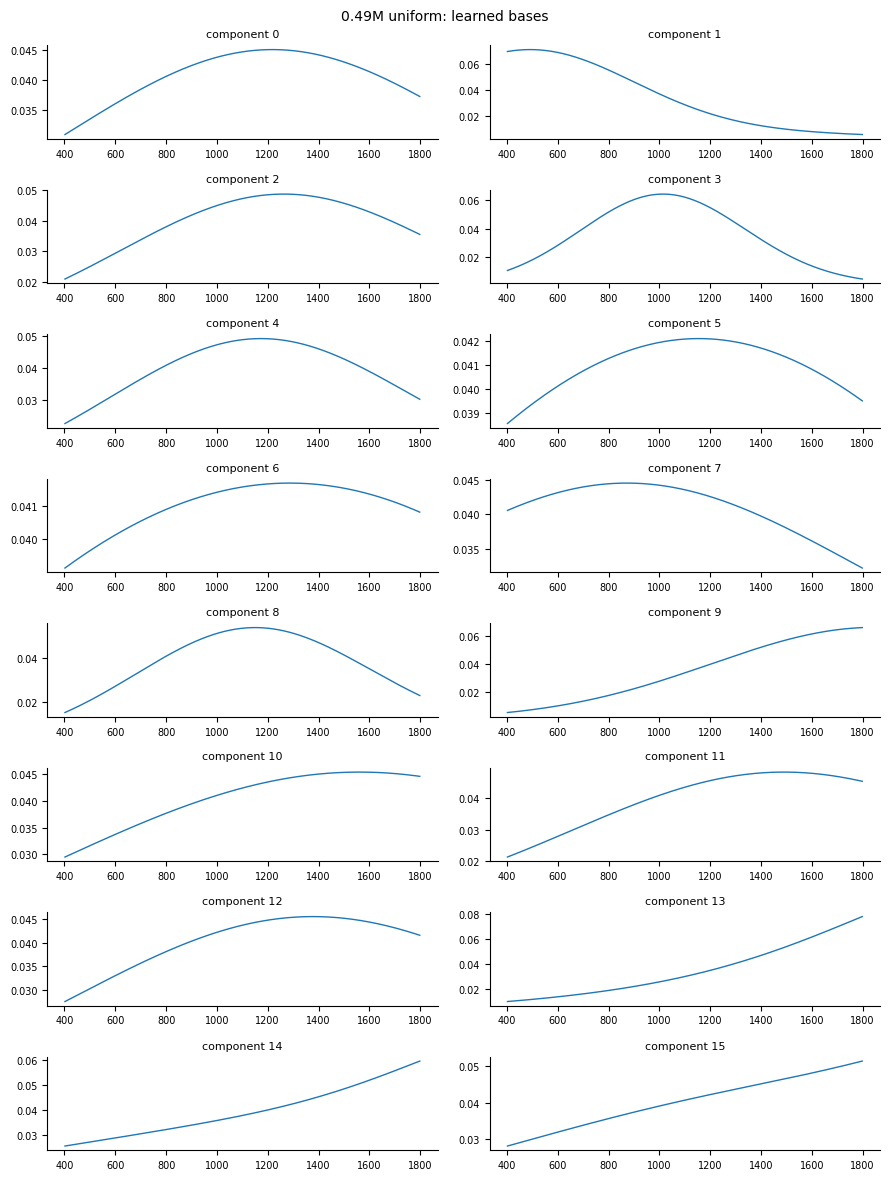

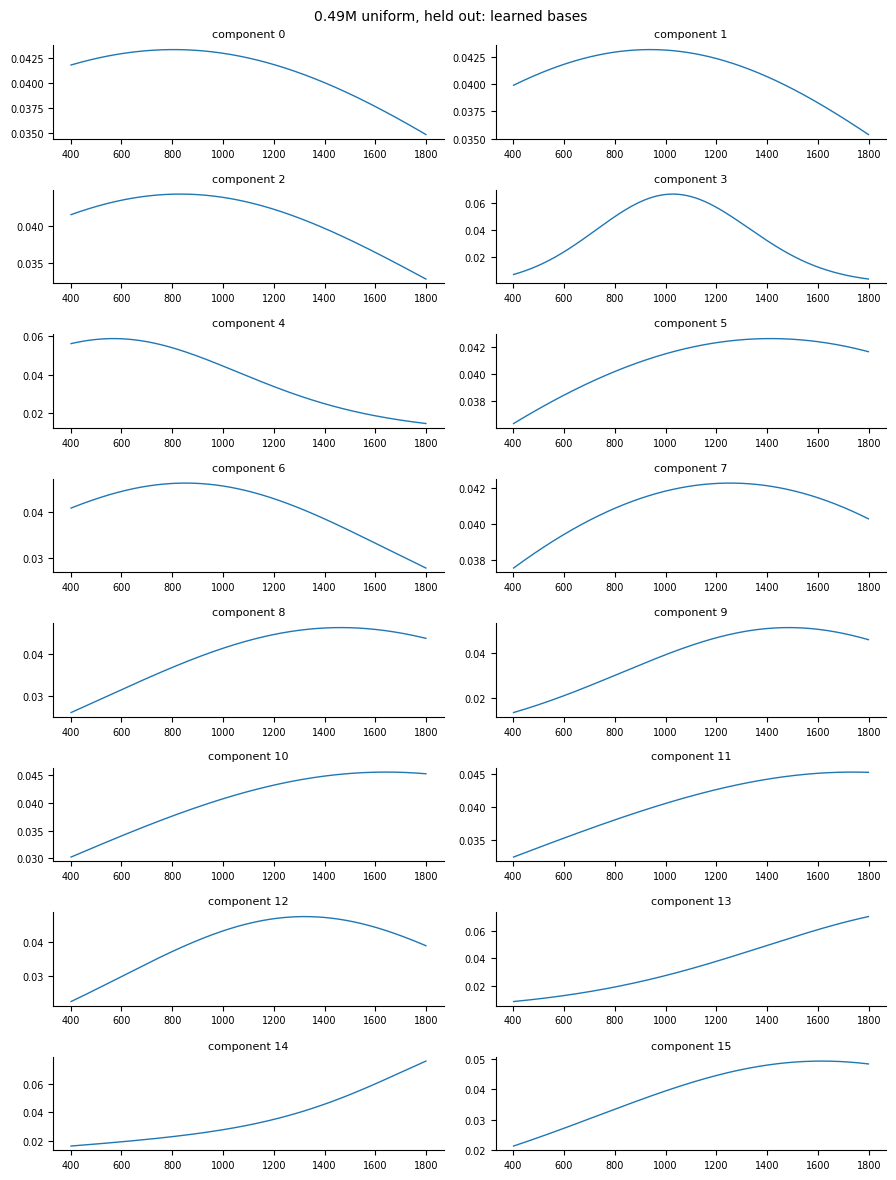

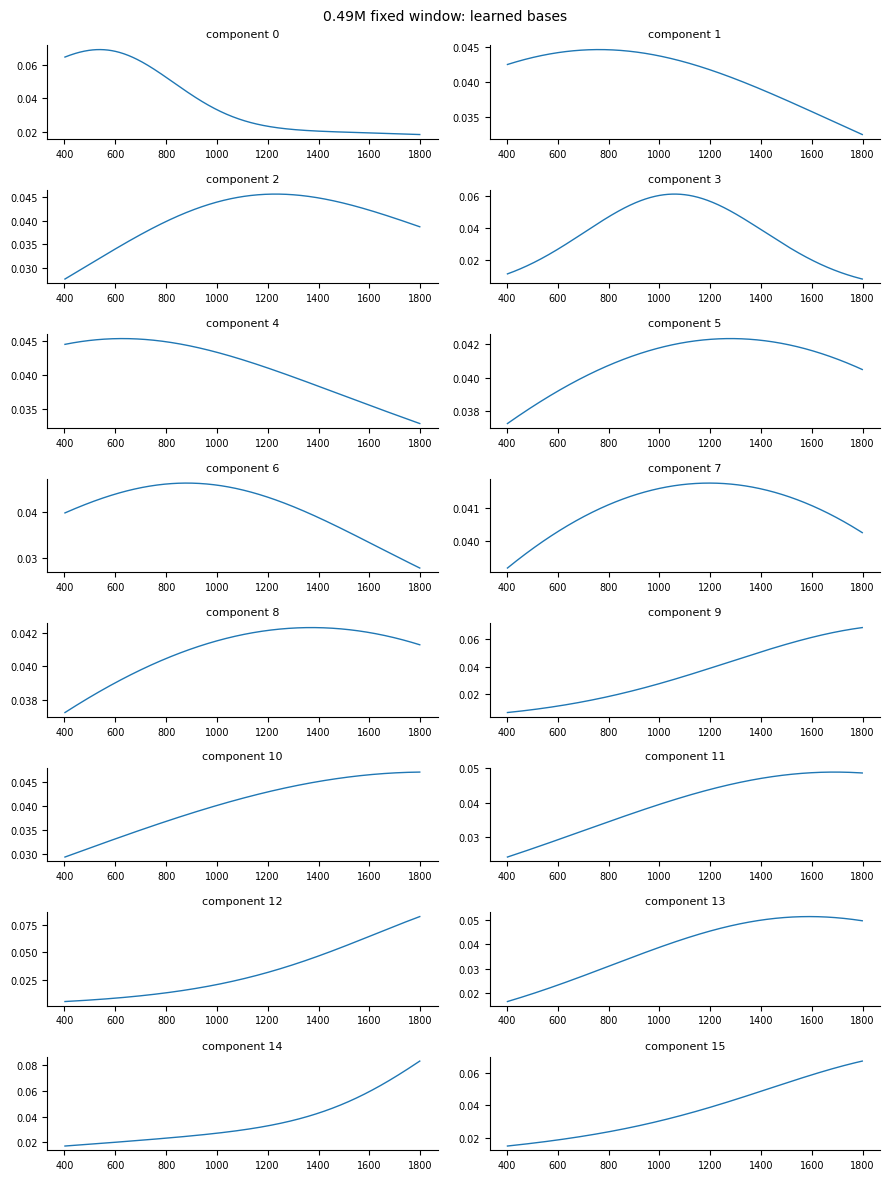

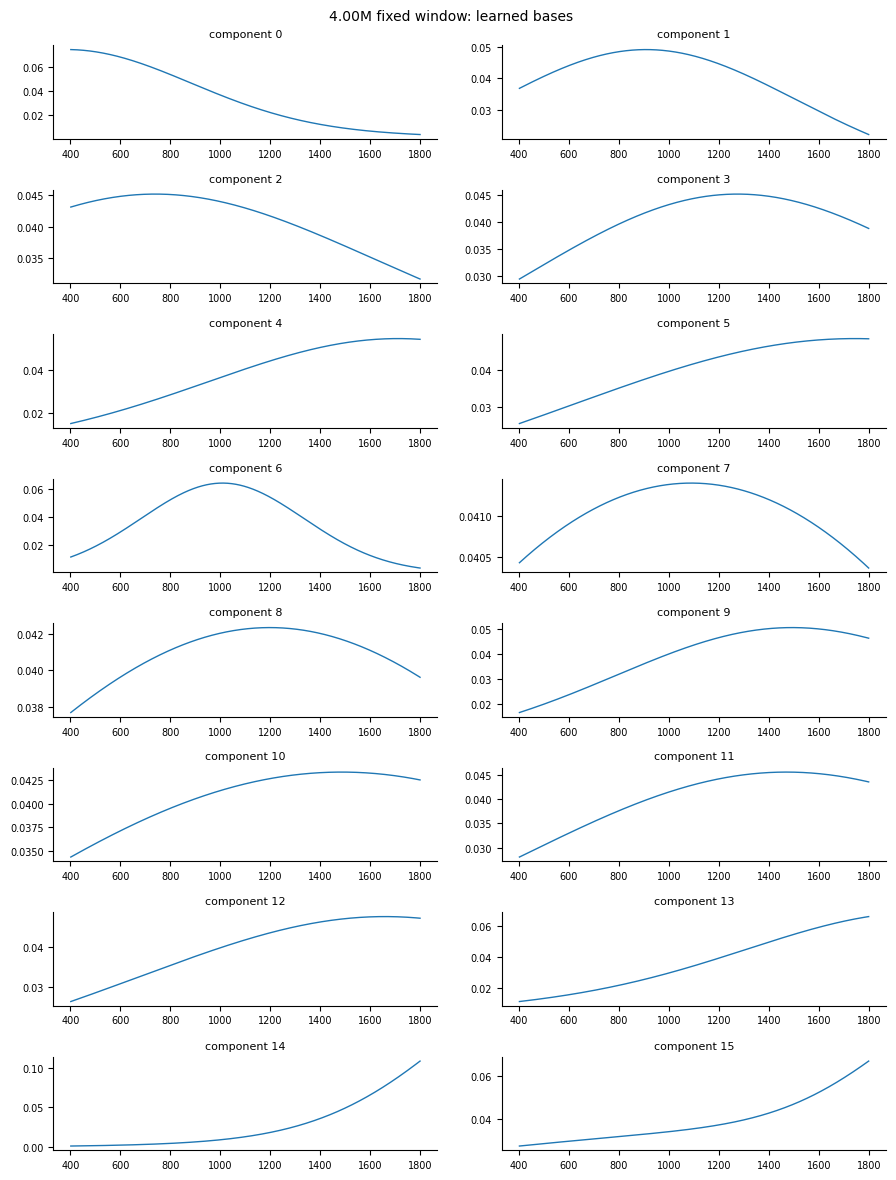

In [17]:
for label, info in model_info.items():
    m = info["model"]
    bases = m.model.bases.detach().cpu().numpy()
    wn = m.model.wavenumbers.detach().cpu().numpy()
    rates = None
    if hasattr(m.model, "log_lambda_global"):
        rates = torch.nn.functional.softplus(
            m.model.log_lambda_global.detach()
        ).cpu().numpy()

    n = bases.shape[0]
    ncol = 2
    fig, axes = plt.subplots(int(np.ceil(n / ncol)), ncol,
                             figsize=(9, 1.5 * n / ncol), squeeze=False)
    for i, ax in enumerate(axes.ravel()[:n]):
        ax.plot(wn, bases[i], lw=1.0)
        title = f"component {i}"
        if rates is not None:
            title += f"   {rates[i]:.3f} s^-1"
        ax.set_title(title, fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=7)
    for ax in axes.ravel()[n:]:
        ax.set_visible(False)
    fig.suptitle(f"{label}: learned bases", fontsize=10)
    plt.tight_layout()
    plt.show()

## Fluorophore identification

Synthetic stores only, since it needs per-sample ground-truth fluorophores.
Components are matched to true fluorophores by the Hungarian assignment on
cosine similarity.

Cosine between broad non-negative spectra saturates near 1 and says little, so
the rate and abundance correlations are the informative numbers.

In [18]:
identification = {}

for label, info in model_info.items():
    d = info["data"]
    if d["bases_gt"] is None:
        print(f"{label}: no ground-truth fluorophores in {d['name']}, skipping")
        continue

    bases = info["model"].model.bases.detach().cpu().numpy()
    bases_n = bases / (np.linalg.norm(bases, axis=1, keepdims=True) + 1e-9)
    rates, abundances = latents[label]["rates"], latents[label]["abundances"]

    cos, true_rate, pred_rate, true_ab, pred_ab = [], [], [], [], []
    for n in range(len(d["idx"])):
        g = d["bases_gt"][n]
        g = g / (np.linalg.norm(g, axis=1, keepdims=True) + 1e-9)
        similarity = g @ bases_n.T
        row, col = linear_sum_assignment(-similarity)
        cos.append(similarity[row, col])
        true_rate.append(d["rates_gt"][n][row])
        pred_rate.append(rates[n][col])
        true_ab.append(d["abund_gt"][n][row] / d["abund_gt"][n].sum())
        pred_ab.append(abundances[n][col] / (abundances[n][col].sum() + 1e-12))

    cos = np.concatenate(cos)
    pairs = tuple(np.concatenate(v) for v in (true_rate, pred_rate, true_ab, pred_ab))
    identification[label] = dict(pairs=pairs, bases=bases, wn=d["wn"])

    gr, pr, ga, pa = pairs
    print(f"{label}   ({bases.shape[0]} model components)")
    print(f"  matched cosine     {cos.mean():.4f}   (saturates, of limited use)")
    print(f"  log rate r         {np.corrcoef(np.log(gr), np.log(pr))[0, 1]:+.4f}")
    print(f"  abundance r        {np.corrcoef(ga, pa)[0, 1]:+.4f}")

0.49M uniform: no ground-truth fluorophores in glasgow_16_trimmed_smoothed.zarr, skipping
0.49M uniform, held out: no ground-truth fluorophores in glasgow_16_trimmed_smoothed.zarr, skipping
0.49M fixed window: no ground-truth fluorophores in glasgow_16_trimmed_smoothed.zarr, skipping
4.00M fixed window: no ground-truth fluorophores in glasgow_16_trimmed_smoothed.zarr, skipping


In [20]:
for label, r in identification.items():
    gr, pr, ga, pa = r["pairs"]
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

    lim = [min(gr.min(), pr.min()), max(gr.max(), pr.max())]
    ax[0].loglog(gr, pr, ".", ms=4, alpha=0.5)
    ax[0].plot(lim, lim, "k--", lw=1)
    ax[0].set(xlabel="true rate (s^-1)", ylabel="predicted",
              title=f"decay rates  r={np.corrcoef(np.log(gr), np.log(pr))[0, 1]:+.3f}")

    ax[1].plot(ga, pa, ".", ms=4, alpha=0.5)
    ax[1].plot([0, 1], [0, 1], "k--", lw=1)
    ax[1].set(xlabel="true fraction", ylabel="predicted",
              title=f"abundance  r={np.corrcoef(ga, pa)[0, 1]:+.3f}")

    for b in r["bases"]:
        ax[2].plot(r["wn"], b / b.max(), lw=0.9)
    ax[2].set(xlabel="wavenumber (cm^-1)",
              title=f"{r['bases'].shape[0]} learned bases")

    for a in ax:
        a.spines[["top", "right"]].set_visible(False)
    fig.suptitle(label, fontsize=10)
    plt.tight_layout()
    plt.show()

### Matched pairs

In [21]:
N_SAMPLES = 6

for label, info in model_info.items():
    d = info["data"]
    if d["bases_gt"] is None:
        continue
    bases = info["model"].model.bases.detach().cpu().numpy()
    bases_n = bases / (np.linalg.norm(bases, axis=1, keepdims=True) + 1e-9)
    n_fluo = d["bases_gt"].shape[1]

    fig, axes = plt.subplots(N_SAMPLES, n_fluo,
                             figsize=(4 * n_fluo, 2.2 * N_SAMPLES), squeeze=False)
    picks = np.linspace(0, len(d["idx"]) - 1, N_SAMPLES, dtype=int)
    for si, n in enumerate(picks):
        g = d["bases_gt"][n]
        g = g / (np.linalg.norm(g, axis=1, keepdims=True) + 1e-9)
        similarity = g @ bases_n.T
        row, col = linear_sum_assignment(-similarity)
        for k in range(min(n_fluo, len(row))):
            ax = axes[si, k]
            true = d["bases_gt"][n][row[k]]
            pred = bases[col[k]]
            ax.plot(d["wn"], true / true.max(), color="black", lw=1.2, label="true")
            ax.plot(d["wn"], pred / pred.max(), color="tab:orange", lw=1.2,
                    ls="--", label="learned")
            name = str(d["dye_names"][n][row[k]]) if d["dye_names"] is not None else ""
            ax.set_title(f"{name}  cos={similarity[row[k], col[k]]:.3f}", fontsize=8)
            ax.spines[["top", "right"]].set_visible(False)
            if si == 0 and k == 0:
                ax.legend(fontsize=7, frameon=False)
    fig.suptitle(f"{label}: true fluorophore against its assigned component", fontsize=10)
    plt.tight_layout()
    plt.show()

## Learned representations

Five per-sample representations from each model. Classes are only meaningful
where a store has few distinct labels; with one label per sample (fish spot IDs,
for instance) points are coloured by initial intensity instead.

In [22]:
def representations(label):
    """Per-sample latent, abundances, rates, fluorescence and Raman."""
    info = model_info[label]
    m, d = info["model"], info["data"]
    n_times = m.hparams.n_times_train
    std = m.model.dataset_std
    device = next(m.parameters()).device

    rates, abundances, raman, mu = [], [], [], []
    with torch.no_grad():
        for i in range(0, len(d["ts"]), 8):
            x = d["ts"][i:i + 8, :, :n_times].astype(np.float32)
            x = torch.from_numpy(x).to(device) / std
            _, _, _, lam, ab, ram, _ = m.model(x, sample=False)
            rates.append(lam.cpu().numpy())
            abundances.append(ab.cpu().numpy())
            raman.append(ram.cpu().numpy())
            mu.append(m.model.encoder(
                x, m.model.wn_norm, m.model.t_norm_full[:n_times]
            )[0].cpu().numpy())

    rates, abundances, raman, mu = (
        np.concatenate(v) for v in (rates, abundances, raman, mu)
    )
    bases = m.model.bases.detach().cpu().numpy()
    fluorescence = (abundances[:, :, None] * bases[None]).sum(1)  # at t=0

    def unit(v):
        return v / (np.linalg.norm(v, axis=1, keepdims=True) + 1e-12)

    return dict(
        label=label,
        data=d,
        reps={
            "latent mu": mu,
            "abundances": abundances / (abundances.sum(1, keepdims=True) + 1e-12),
            "decay rates": np.log(rates),
            "fluorescence": unit(fluorescence),
            "recovered Raman": unit(raman),
        },
    )


reps = {label: representations(label) for label in model_info}
for label, r in reps.items():
    n_classes = len(set(r["data"]["labels"]))
    note = "  (one label per sample, no class structure)" if n_classes > 20 else ""
    print(f"{label:26s} {len(r['data']['labels']):>4} samples, "
          f"{n_classes:>3} distinct labels{note}")

0.49M uniform                54 samples,   4 distinct labels
0.49M uniform, held out      54 samples,   4 distinct labels
0.49M fixed window           54 samples,   4 distinct labels
4.00M fixed window           54 samples,   4 distinct labels


### PCA and UMAP

/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


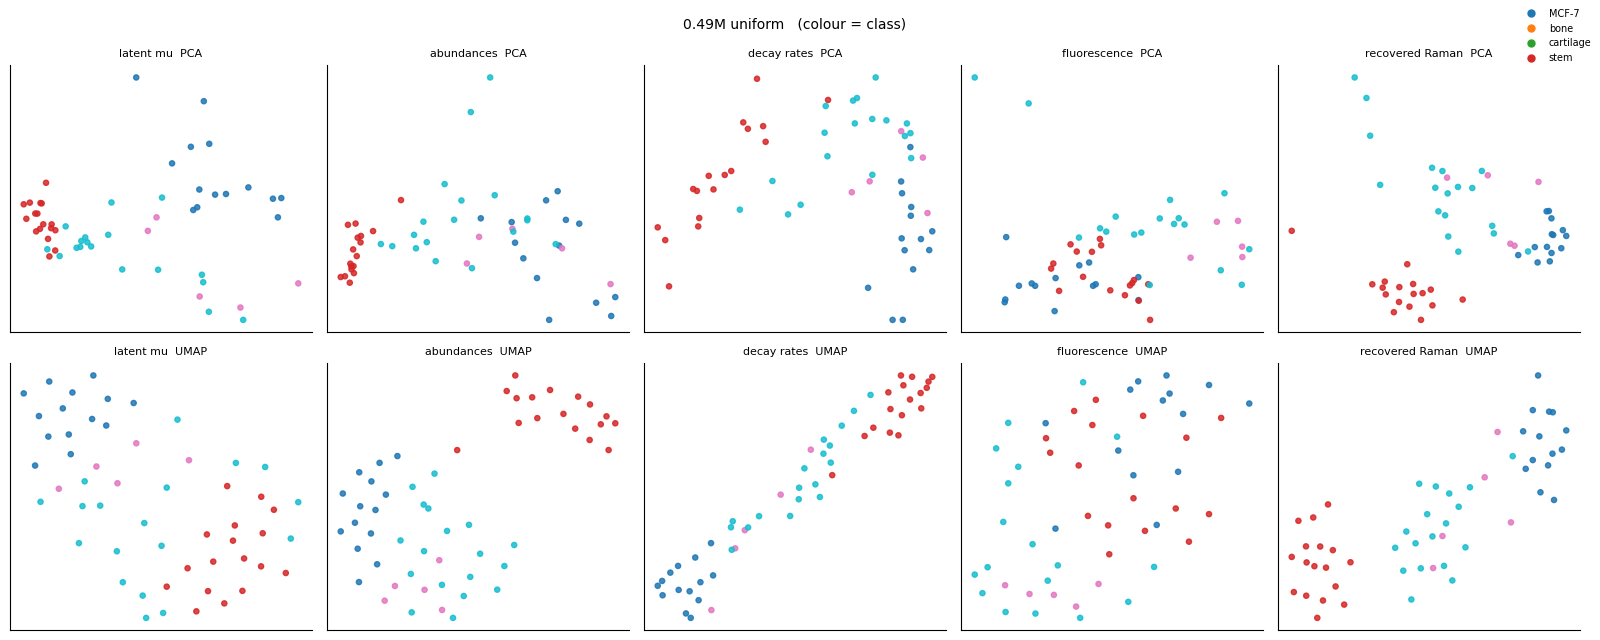

/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


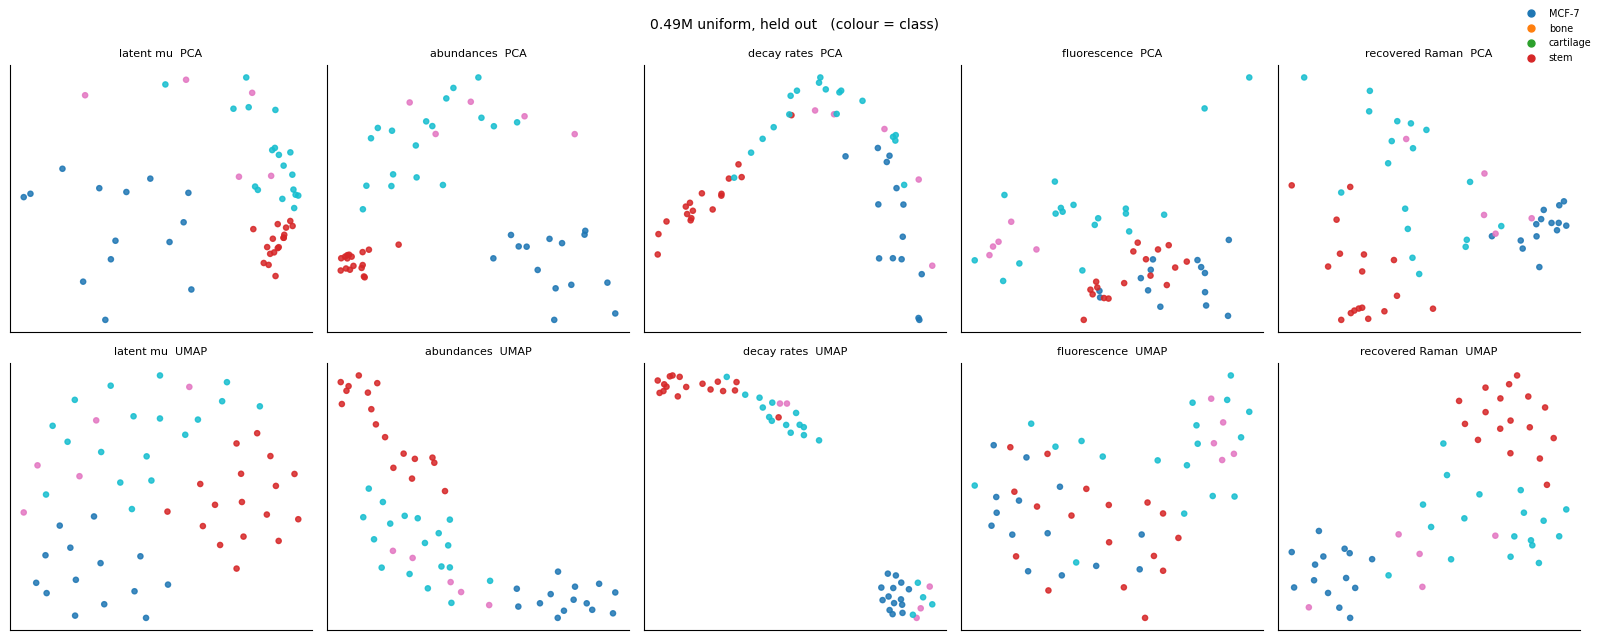

/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


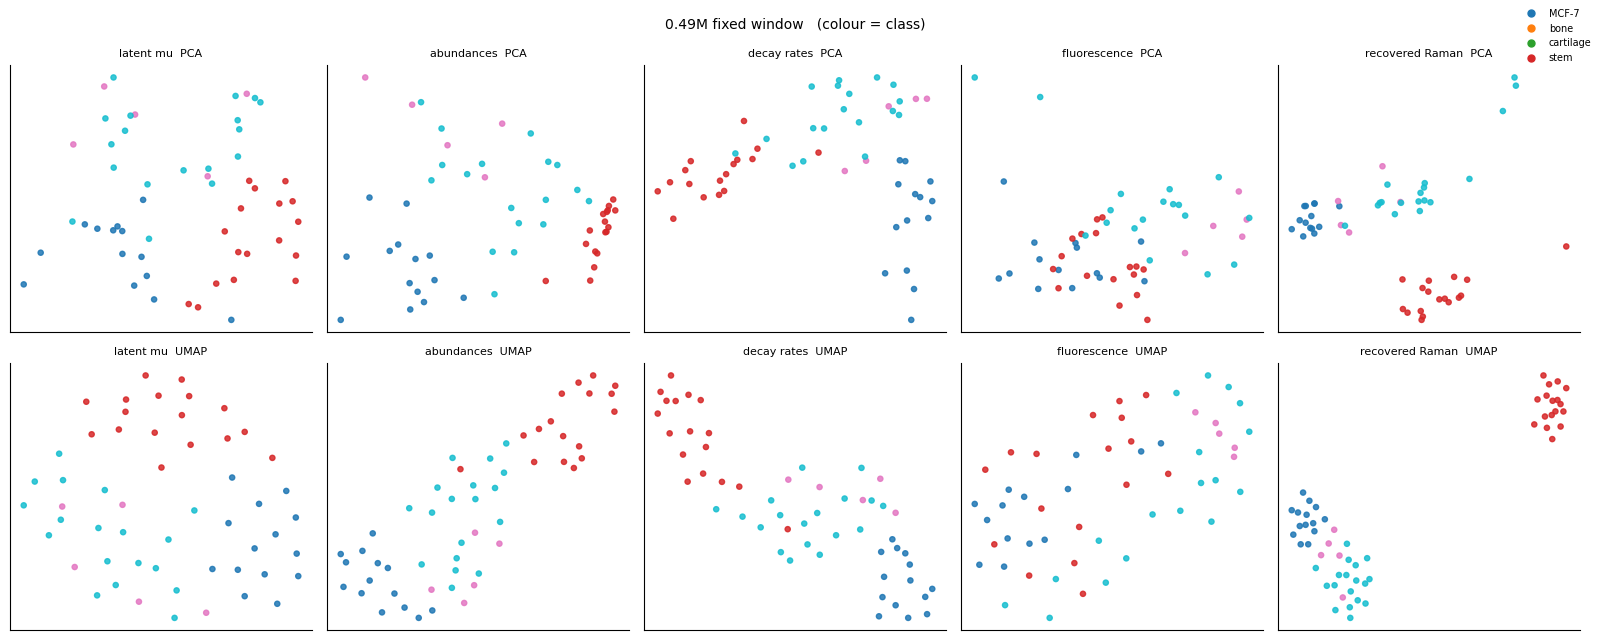

/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


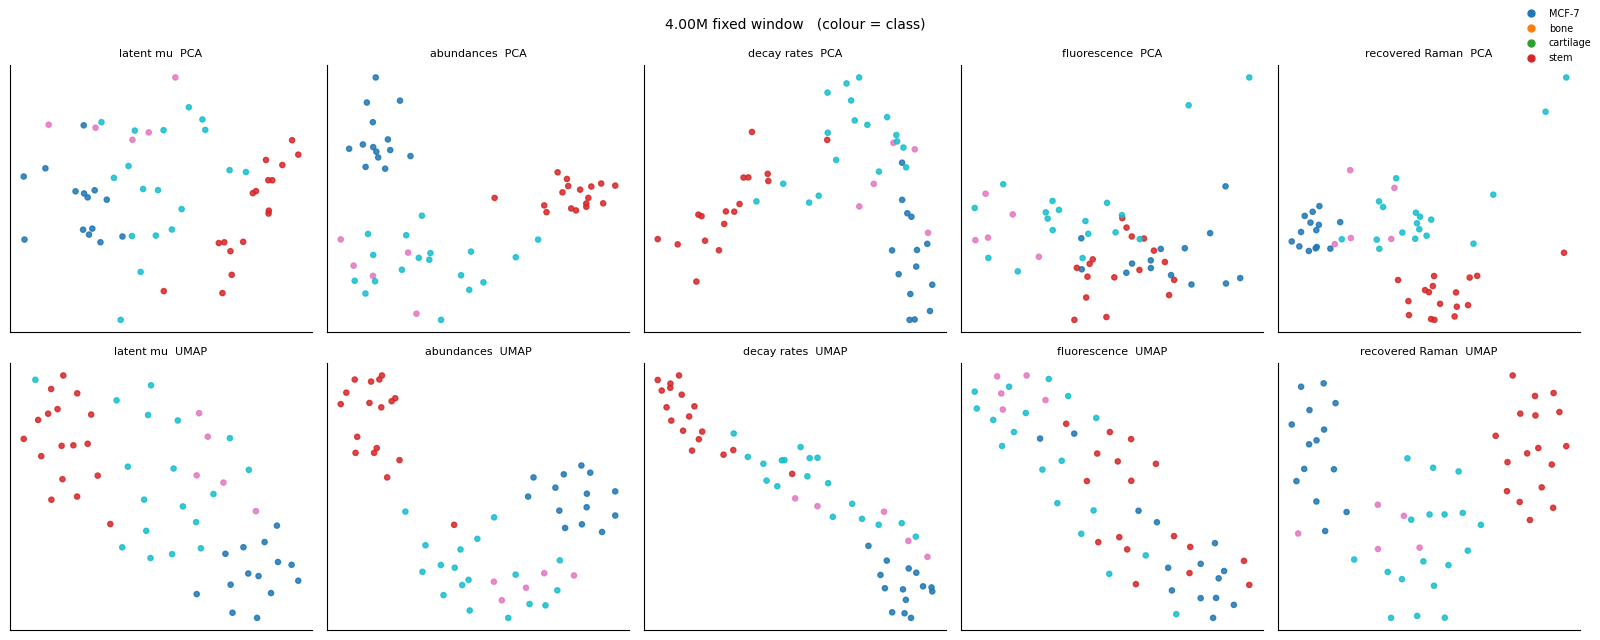

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap

for label, r in reps.items():
    classes = r["data"]["labels"]
    n_classes = len(set(classes))
    has_classes = n_classes <= 20
    colour = (pd.Categorical(classes).codes if has_classes
              else r["data"]["ts"][:, :, 0].mean(1))

    names = list(r["reps"])
    fig, ax = plt.subplots(2, len(names), figsize=(3.2 * len(names), 6.4), squeeze=False)
    for j, name in enumerate(names):
        Z = StandardScaler().fit_transform(r["reps"][name])
        embeddings = [
            (PCA(2).fit_transform(Z), "PCA"),
            (umap.UMAP(n_components=2, random_state=0,
                       n_neighbors=min(15, len(Z) - 1)).fit_transform(Z), "UMAP"),
        ]
        for i, (proj, tag) in enumerate(embeddings):
            a = ax[i, j]
            a.scatter(proj[:, 0], proj[:, 1], c=colour,
                      cmap="tab10" if has_classes else "viridis", s=14, alpha=0.85)
            a.set_title(f"{name}  {tag}", fontsize=8)
            a.set_xticks([])
            a.set_yticks([])
            a.spines[["top", "right"]].set_visible(False)

    if has_classes:
        handles = [plt.Line2D([0], [0], marker="o", ls="", markersize=5,
                              color=plt.cm.tab10(i / 10), label=c)
                   for i, c in enumerate(sorted(set(classes)))]
        fig.legend(handles=handles, loc="upper right", fontsize=7, frameon=False)
    source = "class" if has_classes else "initial intensity"
    fig.suptitle(f"{label}   (colour = {source})", fontsize=10)
    plt.tight_layout()
    plt.show()

### Class information

Cross-validated LDA on each representation. A caveat worth remembering: LDA on
high-dimensional spectra separates even random labels almost perfectly when fit
and scored on the same data, so the cross-validation here is essential, and no
representation can carry more class information than the raw input it came from.

In [25]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

for label, r in reps.items():
    classes = r["data"]["labels"]
    if len(set(classes)) > 20:
        print(f"{label}: {len(set(classes))} distinct labels, no class structure to score")
        continue

    majority = max(np.mean(classes == c) for c in set(classes))
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    print(f"\n{label}   (majority baseline {majority:.3f})")

    # The raw input bounds anything derived from it.
    raw = r["data"]["ts"][:, :, 0]
    raw_acc = cross_val_score(
        make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()), raw, classes, cv=cv
    ).mean()
    print(f"  {'raw first frame':18s} LDA {raw_acc:.3f}   (ceiling)")

    for name, Z in r["reps"].items():
        Z = StandardScaler().fit_transform(Z)
        acc = cross_val_score(
            make_pipeline(LinearDiscriminantAnalysis()), Z, classes, cv=cv
        ).mean()
        sil = silhouette_score(Z, classes)
        print(f"  {name:18s} LDA {acc:.3f}   silhouette {sil:+.3f}")


0.49M uniform   (majority baseline 0.333)
  raw first frame    LDA 0.776   (ceiling)
  latent mu          LDA 0.853   silhouette +0.163
  abundances         LDA 0.815   silhouette +0.250
  decay rates        LDA 0.835   silhouette +0.180
  fluorescence       LDA 0.851   silhouette +0.020
  recovered Raman    LDA 0.778   silhouette +0.274

0.49M uniform, held out   (majority baseline 0.333)
  raw first frame    LDA 0.776   (ceiling)
  latent mu          LDA 0.760   silhouette +0.194
  abundances         LDA 0.871   silhouette +0.298
  decay rates        LDA 0.835   silhouette +0.255
  fluorescence       LDA 0.851   silhouette +0.043
  recovered Raman    LDA 0.762   silhouette +0.211

0.49M fixed window   (majority baseline 0.333)
  raw first frame    LDA 0.776   (ceiling)
  latent mu          LDA 0.724   silhouette +0.177
  abundances         LDA 0.816   silhouette +0.325
  decay rates        LDA 0.855   silhouette +0.235
  fluorescence       LDA 0.871   silhouette +0.016
  recovered R